In [10]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import (
    r2_score, mean_squared_error,
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error)
os.chdir("/Users/matheuspintoarratia/Desktop/quantumblack/deep-rl-mpc/")
from src.bounds import get_bounds_limits
warnings.filterwarnings("ignore")
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.style.use('seaborn-white')
cmap = cm.get_cmap('Spectral')

In [11]:
df = pd.read_csv("data/data_energy_train.csv")
bounds = get_bounds_limits(df, alpha=1)
bounds

  variable  lower_lim  upper_lim
0       at      1.810      37.11
1        v     25.360      81.56
2       ap   1000.990    1025.29
3       rh     41.505     100.16
4       pe    420.260     495.76


,variable,lower_lim,upper_lim
0,at,1.810,37.11
1,v,25.360,81.56
2,ap,1000.990,1025.29
3,rh,41.505,100.16
4,pe,420.260,495.76


In [12]:
df1 = pd.read_csv("./results/test_results/AC2.csv")
df2 = pd.read_csv("./results/test_results/ACKTR.csv")
df3 = pd.read_csv("./results/test_results/DDPG.csv")
df4 = pd.read_csv("./results/test_results/TD3.csv")
df5 = pd.read_csv("./results/test_results/PPO1.csv")
df6 = pd.read_csv("./results/test_results/PPO2.csv")
df7 = pd.read_csv("./results/test_results/TD3.csv")


df = pd.concat([df1, df2, df3, df4, df5, df6, df7], axis=0)
df["mape"] = (df["real"] - df["prediction"]) / df["real"] * 100
df["mape"] = df["mape"].apply(abs)
#df.reset_index(drop=True, inplace=True)



In [13]:
df["model_name"].unique()

array(['AC2', 'ACKTR', 'DDPG', 'TD3', 'PPO1', 'PPO2'], dtype=object)

In [14]:
target = "pe"
control_variables = ["at", "v"]

print("control_variables: ", control_variables)
print("target: ", target)


control_variables:  ['at', 'v']
target:  pe


In [15]:
df["mape"].mean()

0.651961254954852

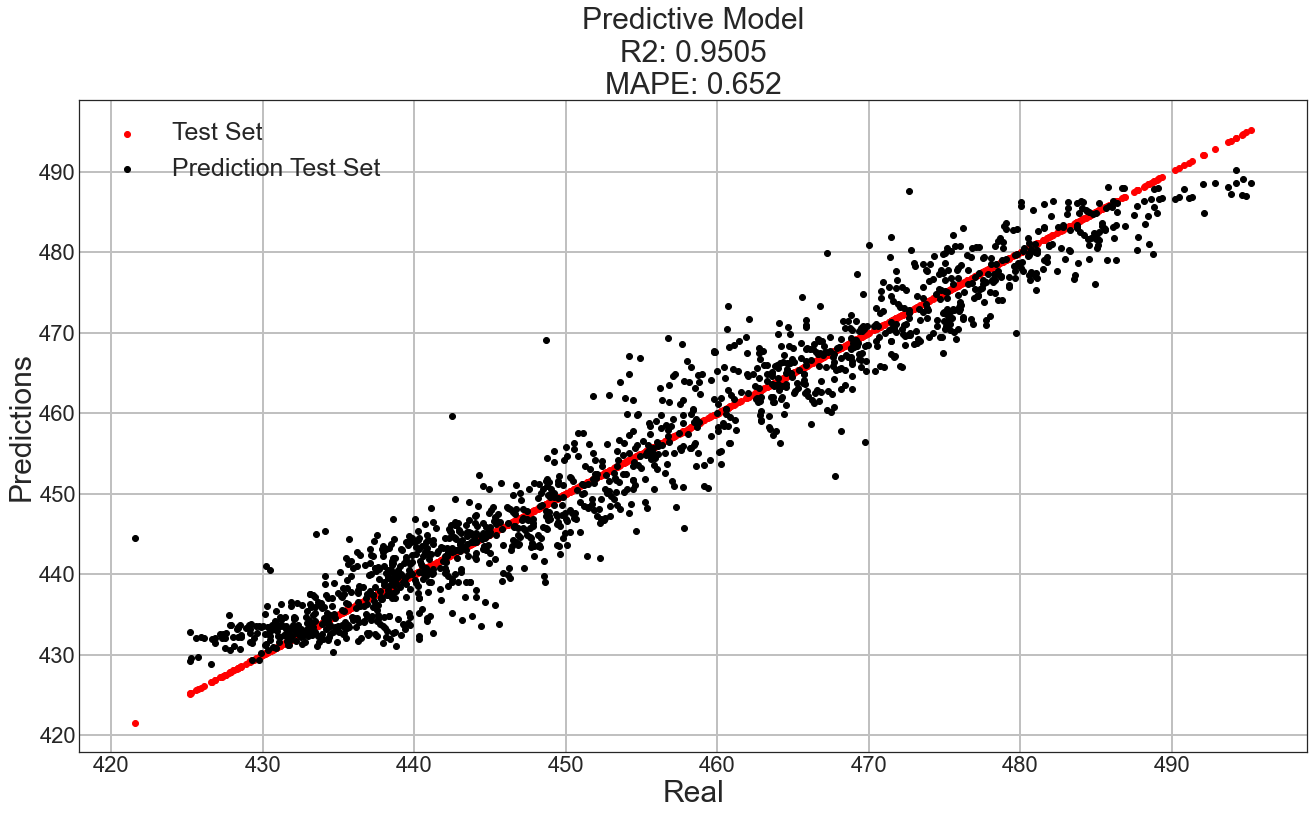

In [34]:
data = df[df["model_name"] == "PPO2"]
data.reset_index(drop=True, inplace=True)
y_pred = np.array(data["prediction"].values)
y_test = np.array(data["real"].values)

def plot_xy_results(y_pred, y_test, name="Regularized Regression"):
    y_pred = np.reshape(y_pred, (-1, 1)) 
    y_test = np.reshape(y_test, (-1, 1)) 
    letter_size = 20
    mae = np.abs(y_pred - y_test).mean()
    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    rmse = np.sqrt(mean_squared_error(y_pred, y_test))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    mae = str(round(mae, 4))
    mape = str(round(mape, 4))
    mse = str(round(mse, 4))
    rmse = str(round(rmse, 4))
    r2 = str(round(r2, 4))

    fig, ax = plt.subplots(1, figsize=(22, 12))
    plt.scatter(y_test, y_test, color='red')
    plt.scatter(y_test, y_pred, color='k')
    title = f"{name}" + "\n" + f"R2: {r2}" + "\n" + f"MAPE: {str(mape)}"
    plt.title(title, fontsize=30)
    plt.xlabel('Real', fontsize=30)
    plt.ylabel('Predictions', fontsize=30)
    plt.grid(color='silver', linestyle='-', linewidth=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(['Test Set', 'Prediction Test Set'], loc='upper left',
               prop={'size': letter_size+5})
    plt.show()

plot_xy_results(y_pred, y_test, name="Predictive Model")

In [35]:
def get_metrics_performance(data):
    
    y_pred = np.array(data["prediction"].values)
    y_test = np.array(data["real"].values)
    y_pred = np.reshape(y_pred, (-1, 1)) 
    y_test = np.reshape(y_test, (-1, 1)) 
    mae = np.abs(y_pred - y_test).mean()
    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    rmse = np.sqrt(mean_squared_error(y_pred, y_test))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    mae = str(round(mae, 4))
    mape = str(round(mape, 4))
    mse = str(round(mse, 4))
    rmse = str(round(rmse, 4))
    r2 = str(round(r2, 4))
    title = "\n" + "Model Metrics:" + "\n" + f"R2: {r2}" + "\n" + f"MAPE: {str(mape)}"
    return title


Model Metrics:
R2: 0.9505
MAPE: 0.652


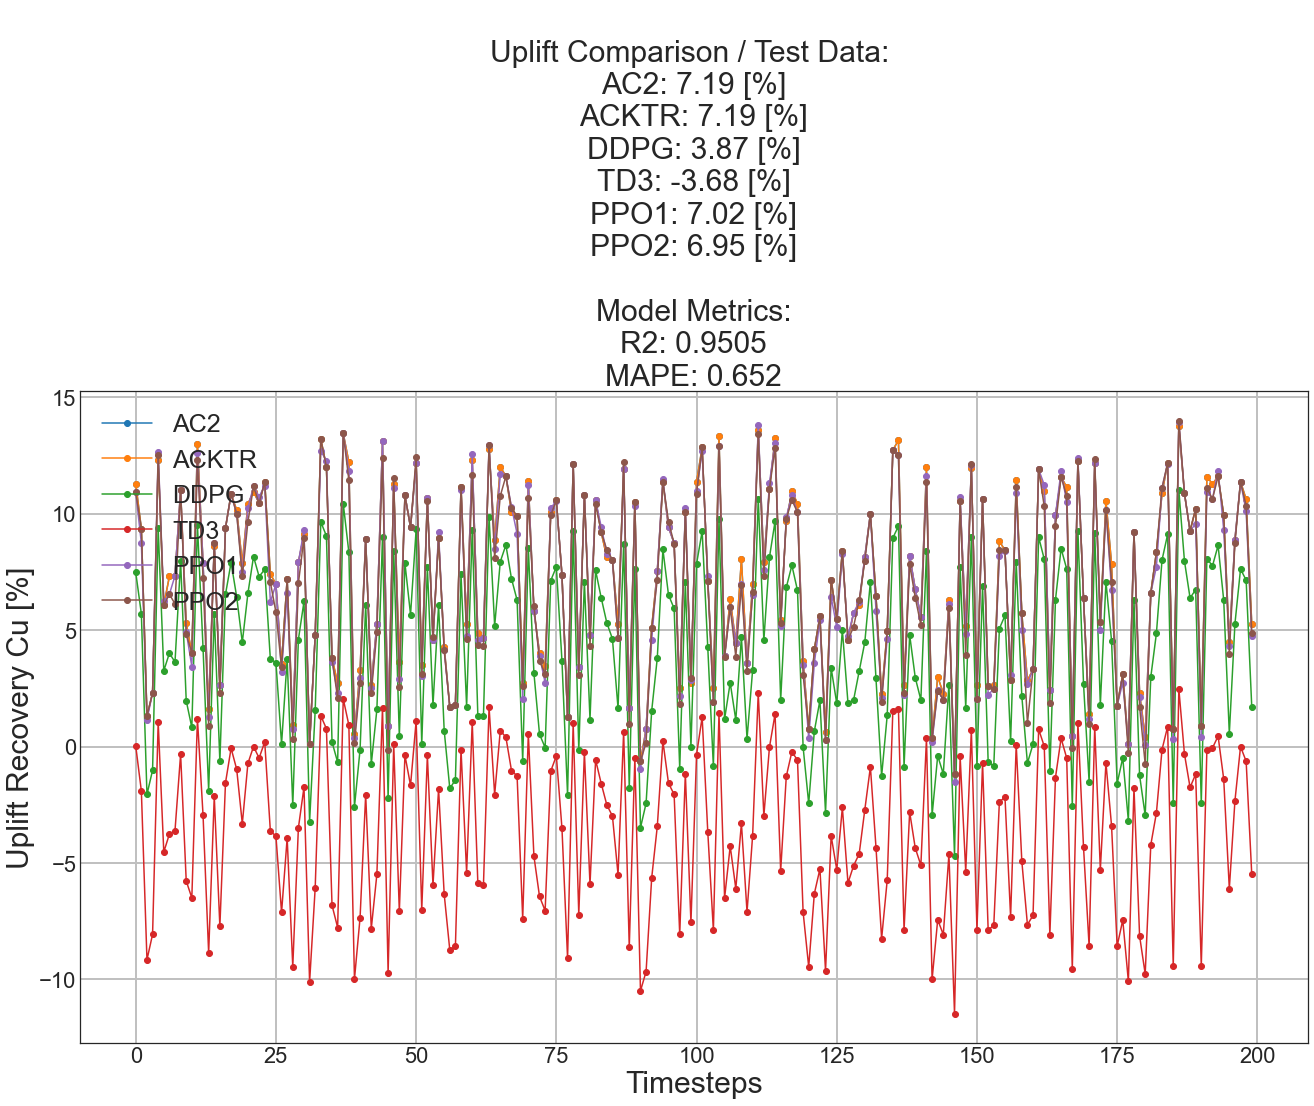

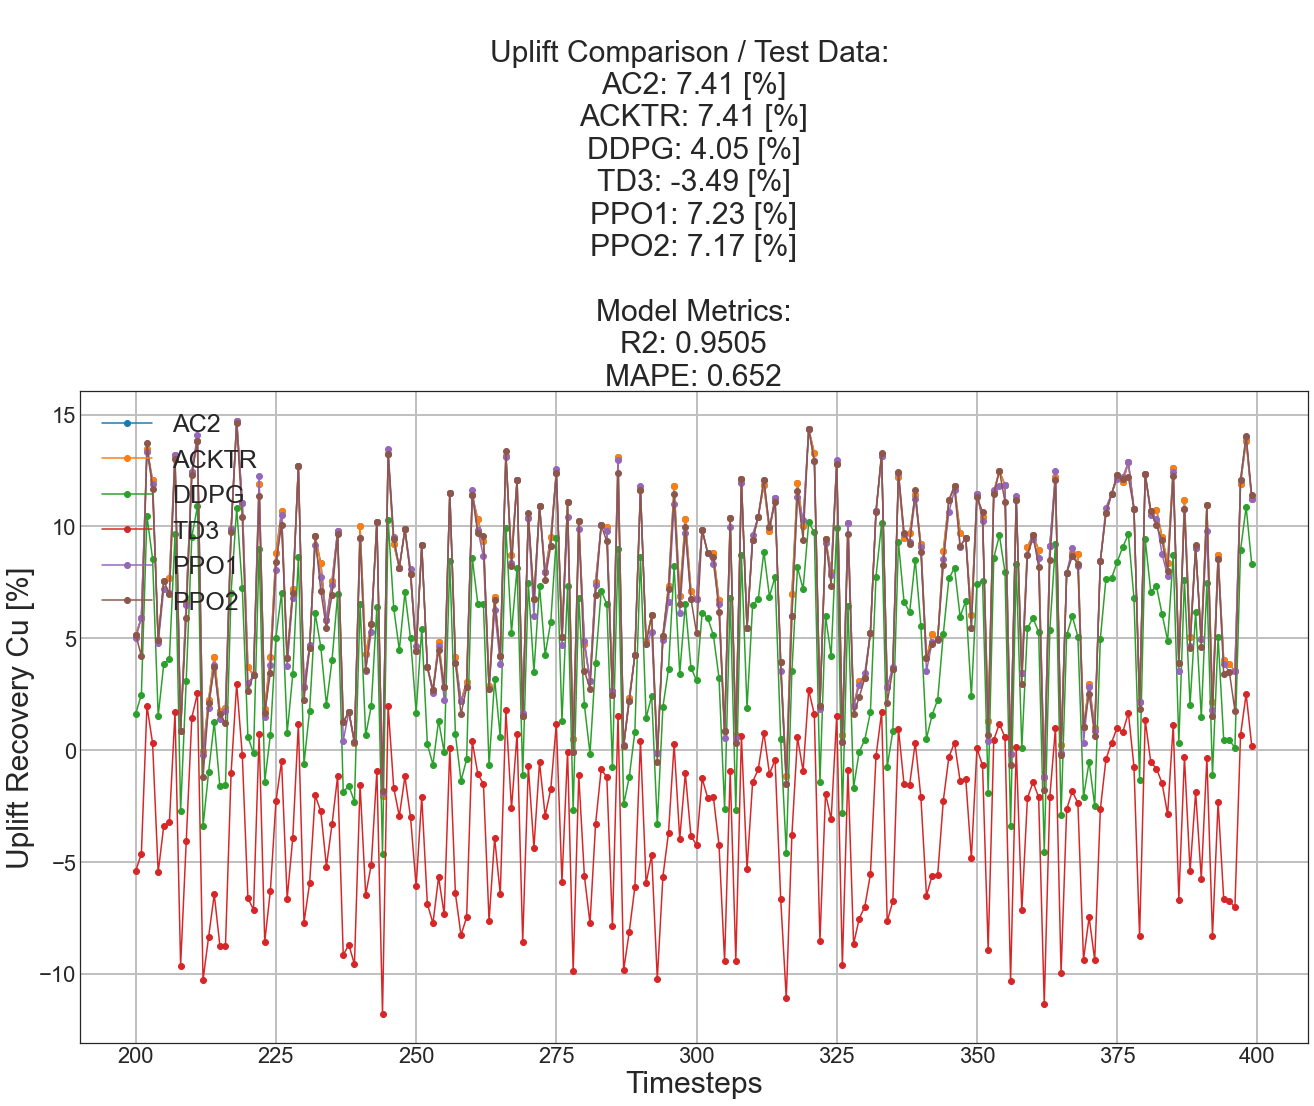

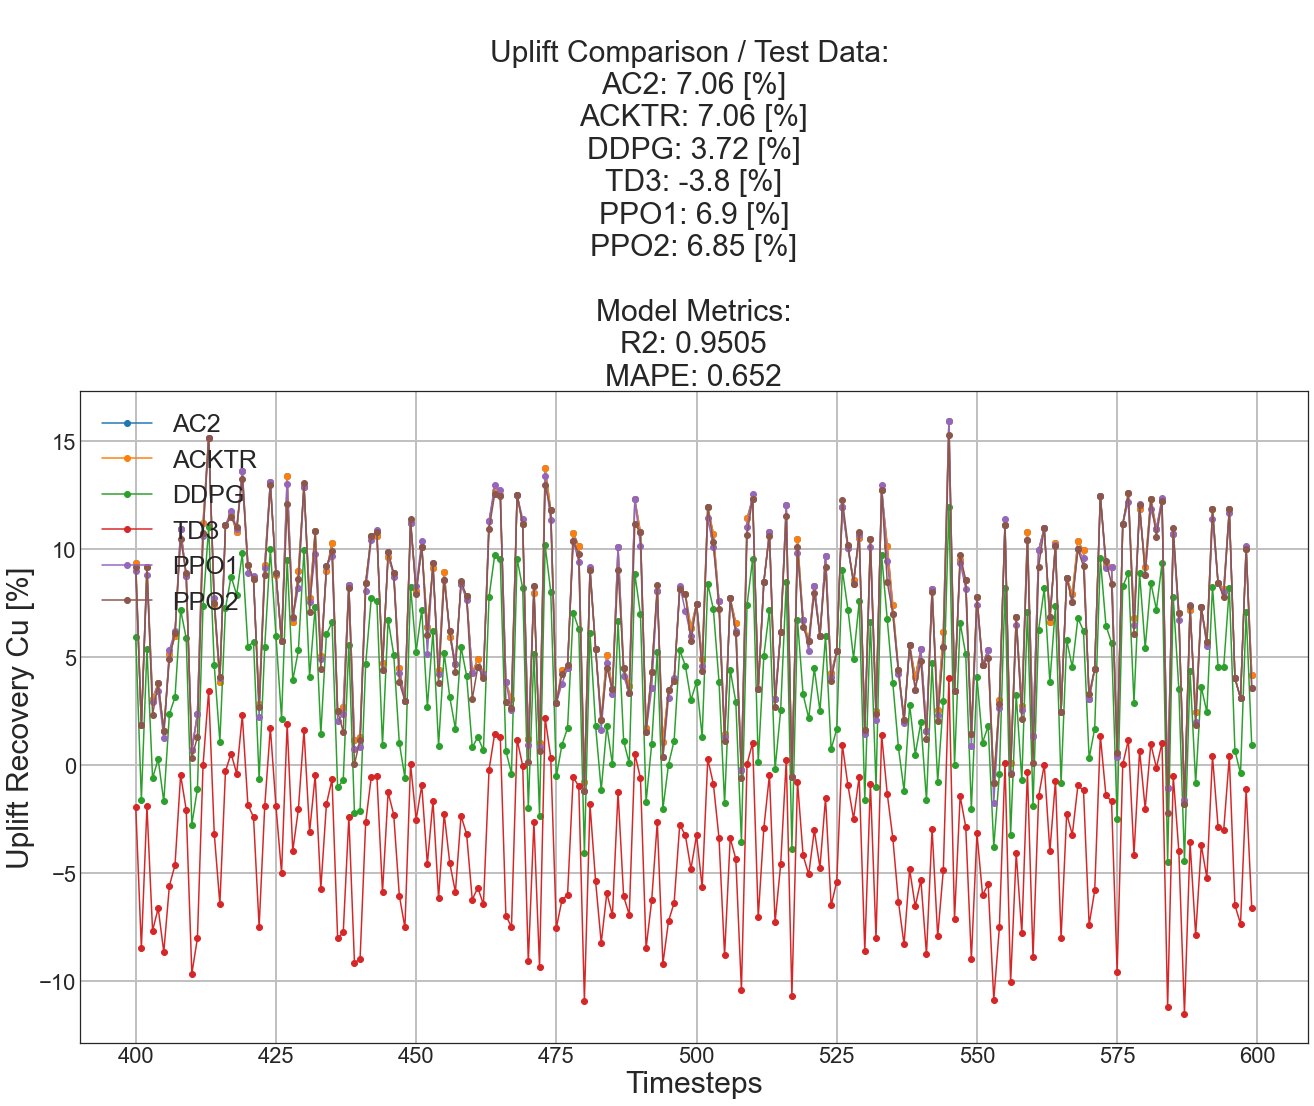

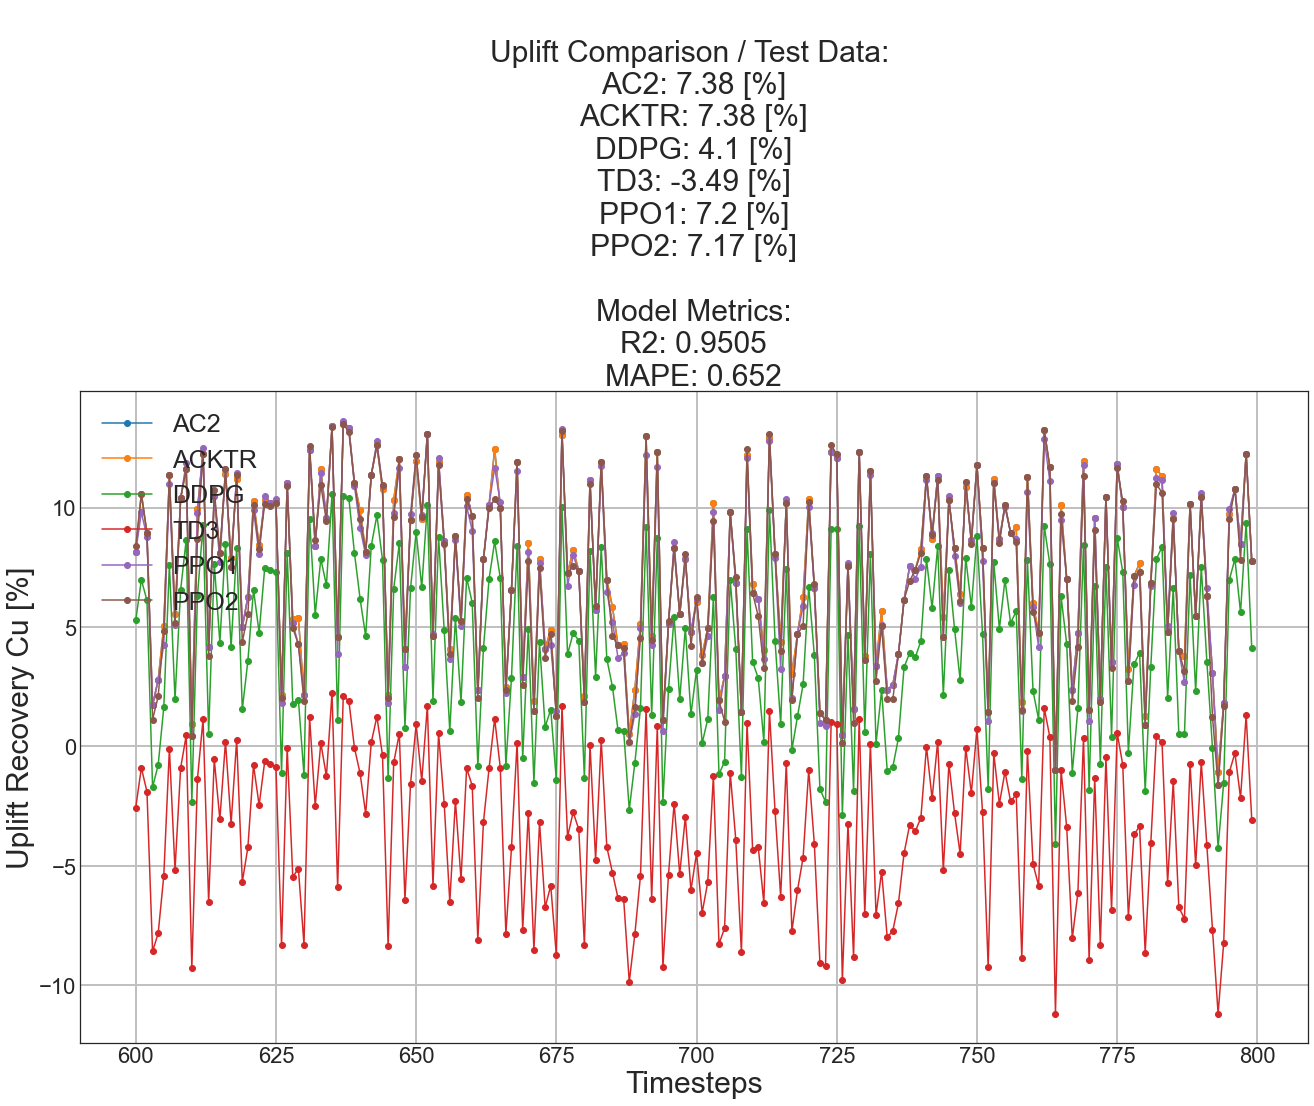

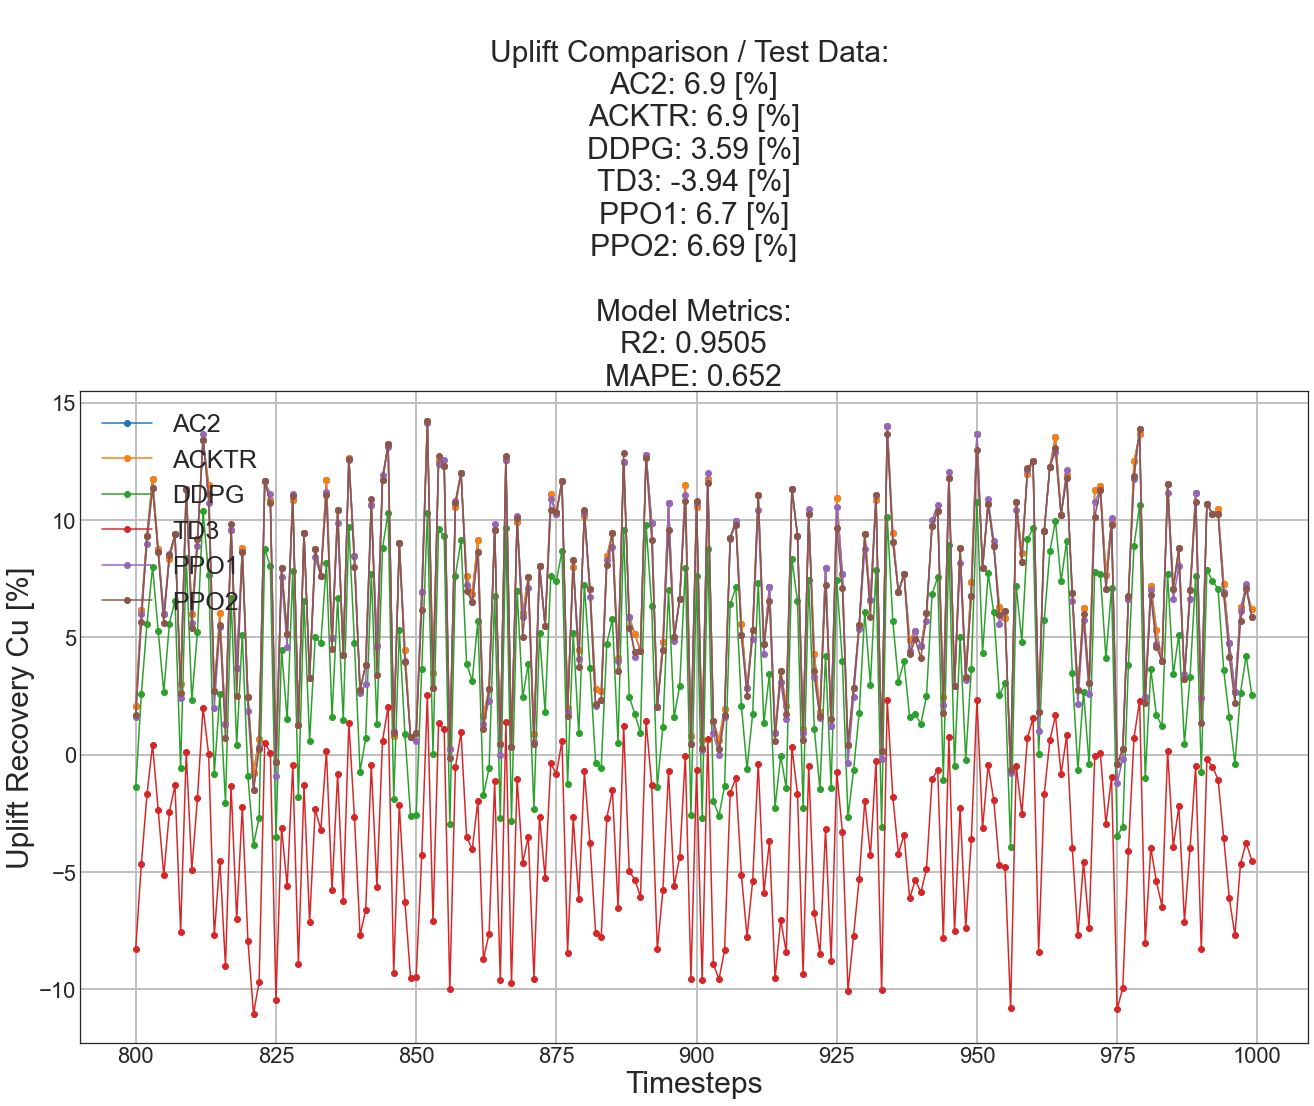

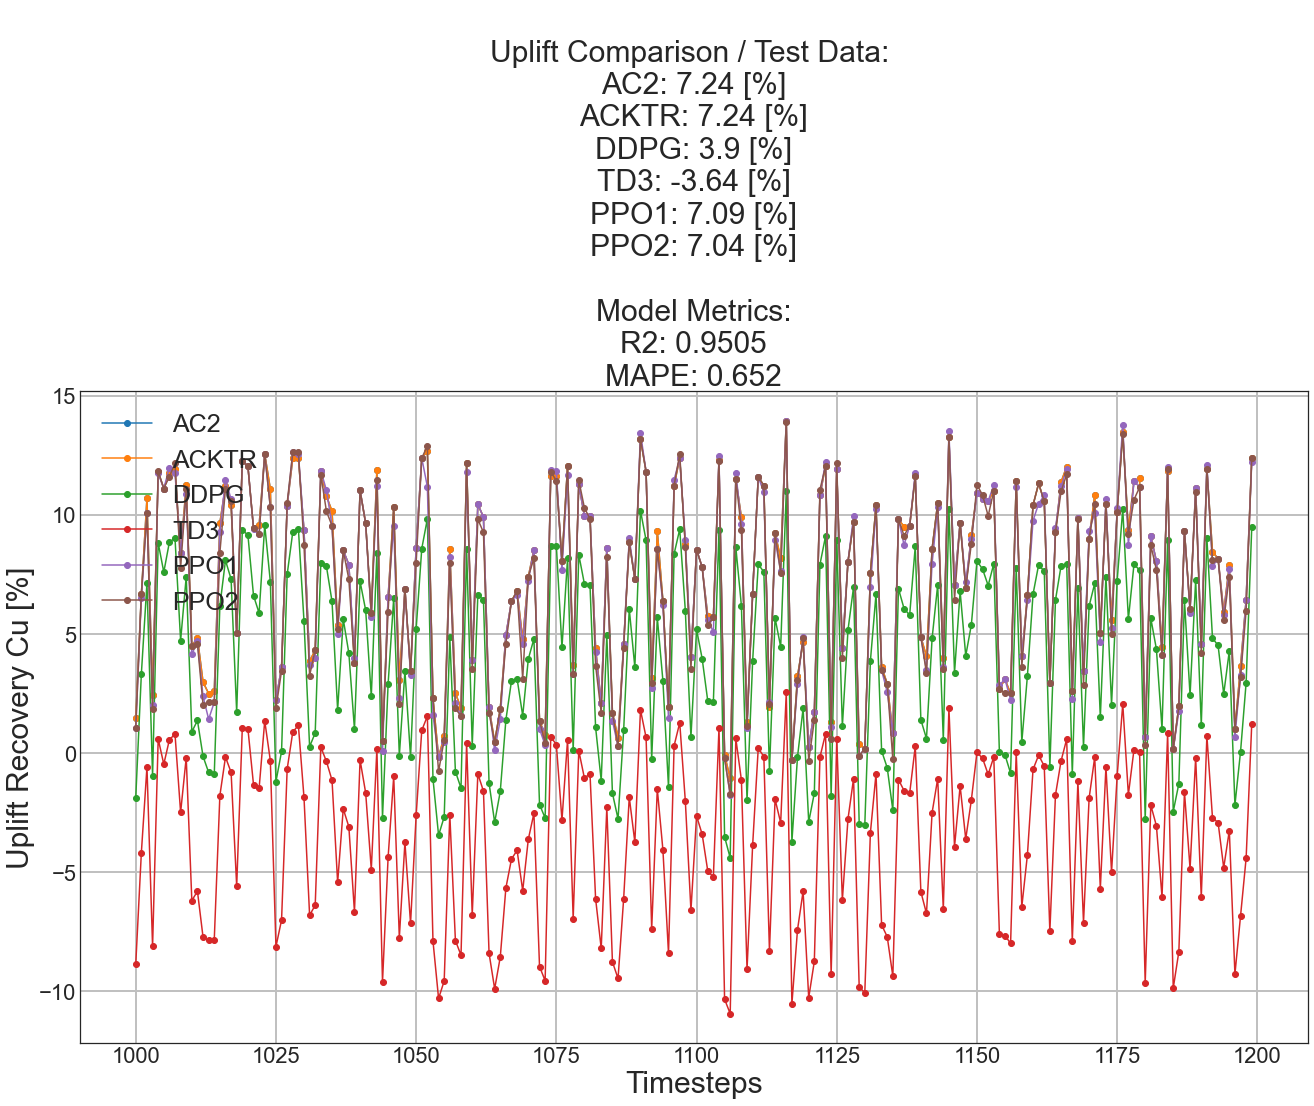

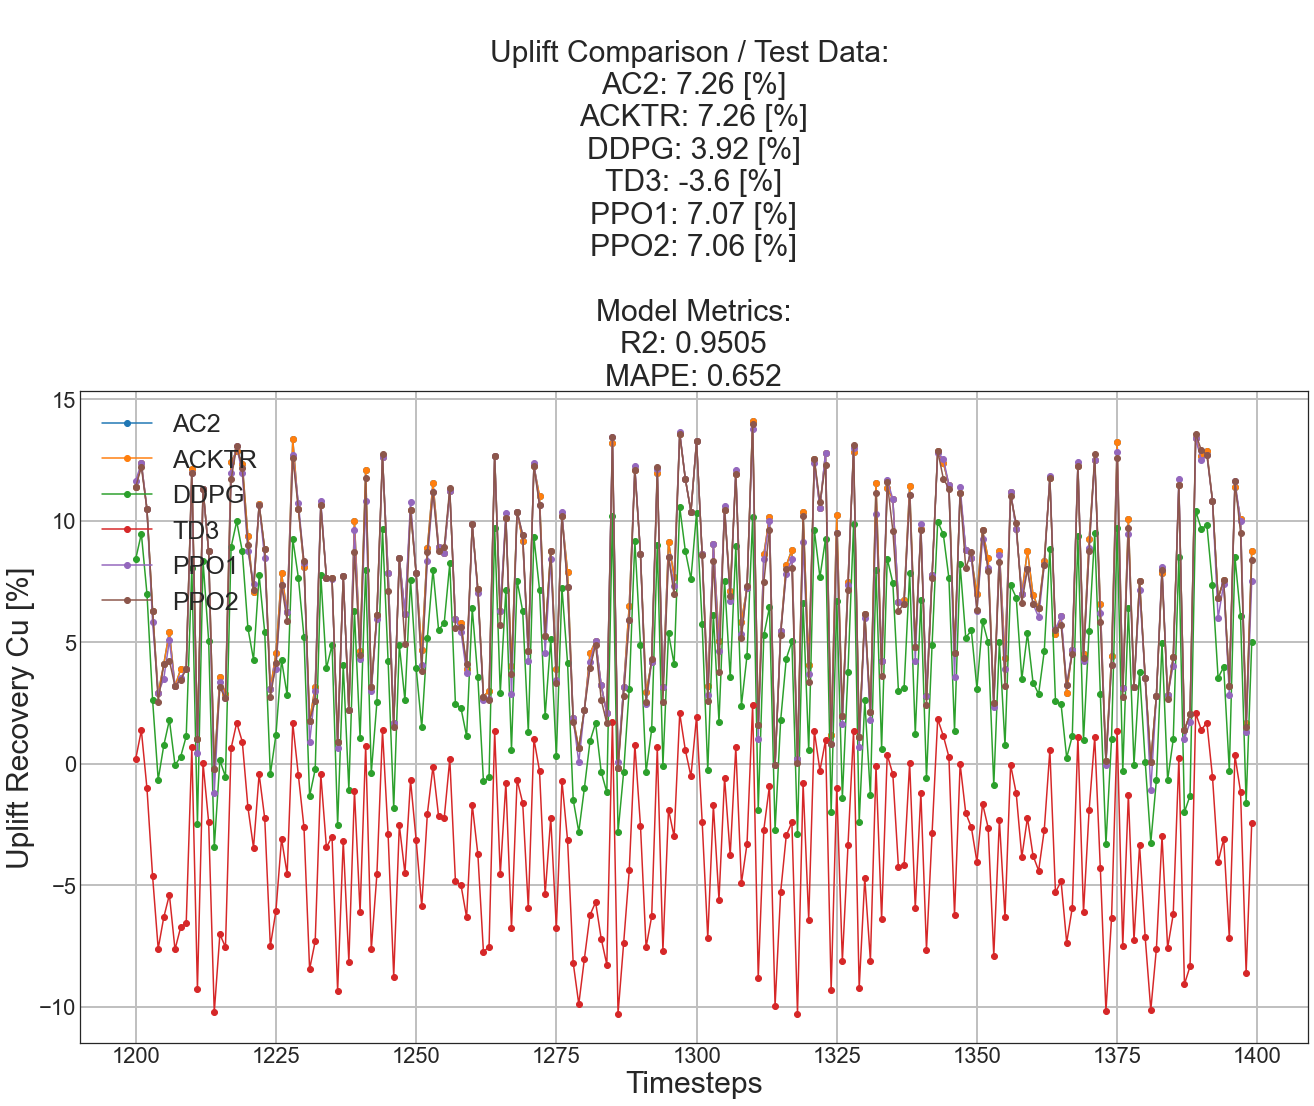

In [36]:

size = 200
categories = list(df["model_name"].unique())

metrics = get_metrics_performance(df[df["model_name"] == "AC2"])

print(metrics)
for i in range(0, len(df1)-size, size):
    fig, ax = plt.subplots(1, figsize=(22, 12))
    title = "\n" + "Uplift Comparison / Test Data: " + "\n"
    legends = []
    for cat in categories:
        data = df[df["model_name"] == cat]
        data["uplift"].iloc[i: i + size].plot(marker="o")
        uplift = round(df[df["model_name"] == cat]["uplift"].iloc[i: i + size].mean(), 2)
        name = cat + ": " + str(uplift) + " [%]" + "\n"
        title += name
        legends.append(cat)
    title += metrics
    graph_title = "Recovery Cu"
    plt.title(title, fontsize=30)
    plt.xlabel('Timesteps', fontsize=30)
    plt.ylabel(f'Uplift {graph_title} [%]', fontsize=30)
    plt.grid(color='silver', linestyle='-', linewidth=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(legends, loc='upper left', prop={'size': 20+5})
    plt.show()

In [23]:
bounds

,variable,lower_lim,upper_lim
0,at,1.810,37.11
1,v,25.360,81.56
2,ap,1000.990,1025.29
3,rh,41.505,100.16
4,pe,420.260,495.76


In [24]:
df[df["model_name"] == "AC2"]

,rec_at,rec_v,at,v,ap,rh,rewards,optimized,prediction,real,uplift,mape,model_name
0,4.048728,25.360001,25.20,65.59,1013.00,71.34,10.282917,488.729035,443.159327,439.14,11.292307,0.915272,AC2
1,4.169288,25.360001,22.19,48.78,1017.84,76.01,8.547198,488.322995,449.871580,446.51,9.364403,0.752857,AC2
2,3.925187,25.360001,8.33,38.08,1018.94,73.78,1.505573,488.189923,480.948888,481.89,1.307336,0.195296,AC2
3,3.915411,25.360001,10.73,44.92,1025.10,85.40,2.431158,487.804225,476.226411,476.81,2.305787,0.122394,AC2
4,3.911211,25.360001,27.10,79.74,1005.43,86.05,11.747029,484.562388,433.624404,431.51,12.294591,0.490001,AC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,4.107308,25.360001,21.82,58.66,1011.71,64.37,8.820005,487.644812,448.120558,452.16,7.847844,0.893366,AC2
1432,3.872701,25.360001,23.98,50.32,1008.41,67.75,9.113705,485.333721,444.796298,443.45,9.444970,0.303596,AC2
1433,3.915349,25.360001,25.42,75.60,1017.39,77.63,11.722944,488.680507,437.403891,438.24,11.509791,0.190788,AC2
1434,3.933535,25.360001,4.49,40.27,1012.01,76.50,-0.179567,487.663264,488.540520,494.24,-1.330677,1.153181,AC2


In [25]:

for model_name in df.model_name.unique():
    print(model_name)
    data = df[df["model_name"] == model_name]
    data.reset_index(drop=True, inplace=True)
    for control_variable in control_variables:
        rec_control_variable = "rec_" + control_variable
        lower_lim = bounds[bounds["variable"] == control_variable]["lower_lim"].values[0]
        upper_lim = bounds[bounds["variable"] == control_variable]["upper_lim"].values[0]
        print(control_variable, rec_control_variable)   

        fig = go.Figure(data=go.Parcoords(
            dimensions=list([
                dict(range=[lower_lim, upper_lim],
                    constraintrange=[0, 1],
                    label=control_variable,
                    values=data[control_variable]), 
                dict(range=[lower_lim, upper_lim],
                    label=rec_control_variable,
                    values=data[rec_control_variable]),
            ])
        )
        )
        fig.show()   

AC2
at rec_at


v rec_v


ACKTR
at rec_at


v rec_v


DDPG
at rec_at


...

v rec_v


PPO1
at rec_at


v rec_v


PPO2
at rec_at


v rec_v
